# ReAct Challenge: Multi-Step Order Assistant

## Build a LangGraph ReAct agent that answers this kind of query:
"user": "I ordered item A123. Check the order status, estimate delivery date, and calculate how many days are left."

## Tech Used

1. LangGraph -- Graph Orchetration
2. Mock Products Data -- dict
3. Terms of Services and Company Policy(Delivery) -- RAG  

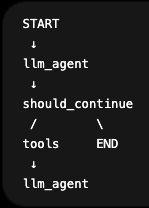

In [1]:
from typing import Annotated, Sequence, TypedDict, Literal
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from datetime import datetime

In [2]:
load_dotenv()

True

In [27]:
product_data = [
    {"id": "product-1", "status": "in_stock", "estimated_delivery_date": "2026-06-16"},
    {"id": "product-2", "status": "in_stock", "estimated_delivery_date": "2026-06-16"},
    {"id": "product-3", "status": "out_of_stock", "estimated_delivery_date": "2026-06-18"}, 
    {"id": "product-4", "status": "out_of_stock", "estimated_delivery_date": "2026-06-18"},
]

In [4]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    status: Literal["in_stock", "out_of_stock"]
    remaining_date: datetime

In [5]:
def select_product(product_id):
    return next(
        (product for product in product_data if product["id"] == product_id),
        None
    ) 

@tool
def check_status(product_id):
    """
    Check the product status by a given product id

    args: product_id: product id of corresponding product data items
    """

    selected_product = select_product(product_id)

    if selected_product is None:
        return {"error": "product not found"}

    return selected_product.get("status", None)


@tool
def check_estimated_delivery_date(product_id):
    """
    Check the estimated delivery date from the data

    args: product_id: product id of corresponding product data items
    """
    selected_product = select_product(product_id)

    return selected_product.get("estimated_delivery_date")


@tool
def check_remianing_days_to_deliver(product_id):
    """
    Check how many days are left to deliver the item to the customer

    args: product_id: product id of corresponding product data items
    """

    selected_product = select_product(product_id)

    # Convert the delivery date(string) into datetime object 
    delivery_date = datetime.strptime(selected_product["estimated_delivery_date"], "%Y-%m-%d")
 
    remaining_days = (delivery_date.date() - datetime.now().date()).days

    return remaining_days
    

In [6]:
class Llm:
    def __init__(self, model): 
        self.model = model
        self.client = None
        self.tools = [check_status, check_estimated_delivery_date, check_remianing_days_to_deliver]

    def initiate_llm(self): 
        self.client = ChatOpenAI().bind_tools(self.tools)

    def reason(self, system_msg: SystemMessage, user_msg:Sequence[BaseMessage]):
        try:
            if self.client == None: 
                self.initiate_llm()

            return self.client.invoke([system_msg] + user_msg) 
                
        except Exception as e:
            raise f"Calling LLM caused an error: {e}"

In [7]:
def llm_agent(state: State) -> State:
    system_message = SystemMessage(content="You are a customer service agent that serves user questions and inquiries".strip())

    
    llm = Llm(model="gpt-5.4-mini")
    response = llm.reason(
        system_message, 
        state["messages"]
    )

    return {"messages": [response]}

In [8]:
### Strictly, this is not needed as tool results return and are passed just within ToolMessages
### But just in terms of practice with State flowing, this update_states node acts as a state updater
def update_states(state: State) -> State: 

    last_message = state["messages"][-1]

    if not isinstance(last_message, ToolMessage): 
        return {}
    
    if last_message.name == "check_status": 
        return {"status": last_message.content}

    if last_message.name == "check_remianing_days_to_deliver":
        return {"remaining_date": last_message.content}

    return {}

In [22]:
def should_continue(state): 
    """
    Conditional node that decides whether to continue or end the tool calling
    """

    messages = state["messages"]
    last_message = messages[-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "continue"

    return "end"

In [23]:
builder = StateGraph(State)
builder.add_node("llm_agent", llm_agent)

llm = Llm(model="gpt-5.4-mini")
llm_tools = llm.tools
tool_node = ToolNode(tools=llm_tools)
builder.add_node("tools", tool_node)

builder.add_node("update_states", update_states)

builder.add_edge(START, "llm_agent")
builder.add_conditional_edges(
    "llm_agent",
    should_continue,
    {
        "continue": "tools", 
        "end": END
    }
)
builder.add_edge("tools", "update_states")
builder.add_edge("update_states", "llm_agent")

graph = builder.compile()

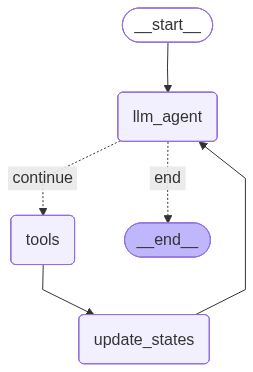

In [24]:
builder.compile()

In [43]:
def print_stream(stream): 
    for s in stream: 
        print(f"======{type(s["messages"][-1]).__name__}======")
        print(f"{s["messages"][-1].content}\n" if s["messages"][-1].content else "Tool Calling\n")

    print("======FINISHED=======")

In [44]:
inputs = {
        "messages": [
        (
            "user", 
            "I ordered item id: product-1. Check the order status, estimate delivery date, and calculate how many days are left."
        )
    ]
}

print_stream(graph.stream(inputs, stream_mode="values"))

======HumanMessage======
I ordered item id: product-1. Check the order status, estimate delivery date, and calculate how many days are left.

======AIMessage======
Tool Calling
======ToolMessage======
2

======ToolMessage======
2

======AIMessage======
- **Order Status:** In Stock
- **Estimated Delivery Date:** June 16, 2026
- **Days Left for Delivery:** 2 days

======FINISHED=======


In [ ]:
### Output

input_arg = {
    "messages": [
        (
            "user", 
            "I ordered item id: product-1. Check the order status, estimate delivery date, and calculate how many days are left."
        )
    ]
}

result = graph.invoke(input_arg)

for msg in result["messages"]:
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(type(msg).__name__, f": {msg.tool_calls[0]["type"]}/{msg.tool_calls[1]["name"]}")
    else:
        print(type(msg).__name__, ":", msg.content)